In [ ]:
from google.colab import drive
import os

# Montar Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path_proyecto = "/content/drive/MyDrive/2026-1/Ciencia de Datos 2/FINAL/Actas"
archivos = [f for f in os.listdir(path_proyecto) if f.endswith('.pdf')]
print(f"Se encontraron {len(archivos)} archivos PDF para procesar.")

Se encontraron 11 archivos PDF para procesar.


### Paso 1: Revisión de 1 Acta



In [ ]:
!pip install pypdf
from pypdf import PdfReader

lector = PdfReader('/content/drive/MyDrive/2026-1/Ciencia de Datos 2/FINAL/Actas/20250908.pdf')
texto_pagina_1 = lector.pages[0].extract_text()

In [ ]:
print(texto_pagina_1)

UNIVERSIDAD NACIONAL AGRARIA LA MOLINA 
FACULTAD DE ECONOMÍA Y PLANIFICACIÓN 
 
“Año del Bicentenario, de la consolidación de nuestra Independencia, y 
de la conmemoración de las heroicas batallas de Junín y Ayacucho” 
 CONSEJO DE FACULTAD ECONOMÍA Y PLANIFICACIÓN 
ACTA DE LA SESIÓN ORDINARIA N° 08-2025-FEP   
DEL 08 DE SETIEMBRE DE 2025 
  
Página 1 de 31 
Av. La Molina s/n La Molina - Lima - Lima – Perú         Telf: 614 7131 / 614 7800 anexo 204 
     feconomia@lamolina.edu.pe     https://web.lamolina.edu.pe/facultadeconomia/ 
 
Siendo la 13:04 p.m. del 08 de setiembre de 2025, el señor Decano Dr. Elías Félix Huerta Camones dio inicio a 
la sesión ordinaria del Consejo de Facultad, con la asistencia de los siguientes miembros con voz y voto: 
 
Docentes:   
1. Dr. Elias Felix Huerta Camones (Decano) 
2. Dr. Waldemar Fernando Mercado Curi 
3. Dr. Luis Alberto Jiménez Díaz  
4. MBA Carlos Alberto Guerrero López  
5. Dr. Ernesto Héctor Maguiña Salinas 
6. Maest. Eco. Karina Marlen Yach

In [ ]:
# Instalar poppler (herramienta del sistema para manejar PDFs)
!apt-get update
!apt-get install -y poppler-utils

# Instalar la librería de Python
!pip install --quiet pdf2image

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,183 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,303 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,006 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [

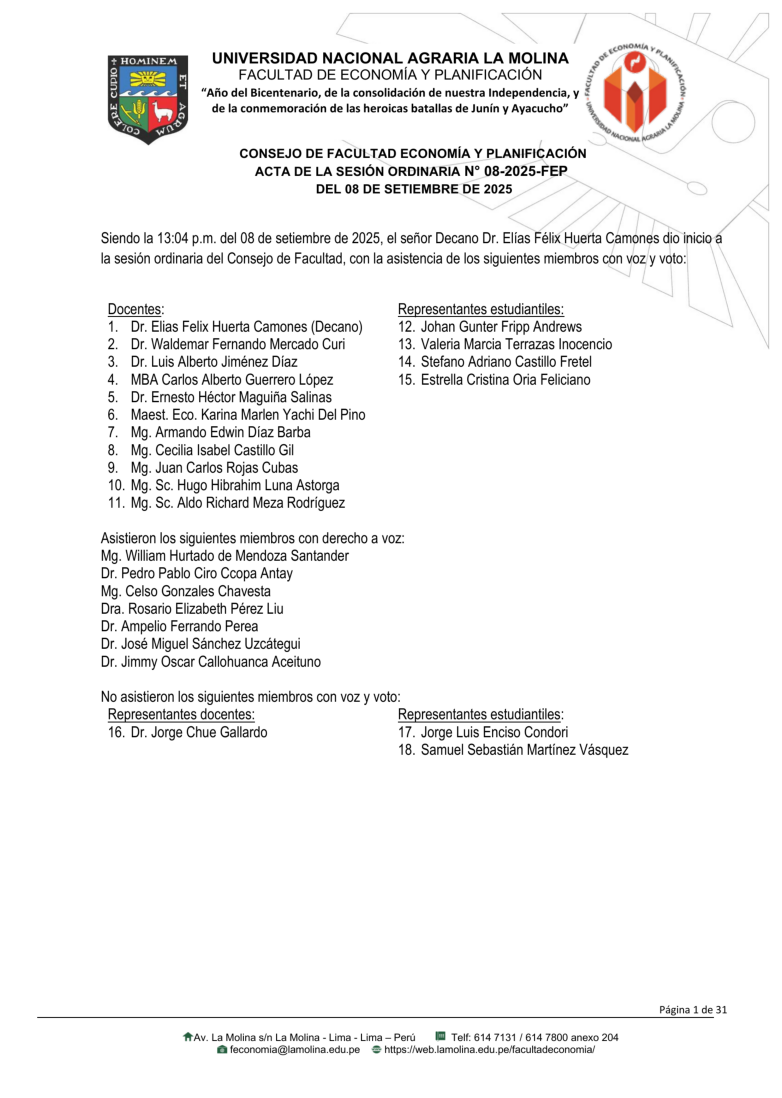

In [ ]:
from pdf2image import convert_from_path
import matplotlib.pyplot as plt

# Definir la ruta exacta de tu archivo
ruta_pdf = '/content/drive/MyDrive/2026-1/Ciencia de Datos 2/FINAL/Actas/20250908.pdf'

# Convertir solo la primera página (first_page=1, last_page=1)
paginas_como_imagenes = convert_from_path(ruta_pdf, first_page=1, last_page=1)

# Como pedimos solo una página, tomamos el primer elemento de la lista
primera_pagina_img = paginas_como_imagenes[0]

# Configurar el tamaño del gráfico en matplotlib para que se vea grande y legible
plt.figure(figsize=(10, 14))
plt.imshow(primera_pagina_img)
plt.axis('off')  # Ocultar los ejes de coordenadas (X e Y)
plt.show()

### Paso 2: Limpieza

In [ ]:
import os
import re
import json
import pickle
import pandas as pd
from pypdf import PdfReader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Aseguramos que la lista de archivos esté bien mapeada
archivos = [f for f in os.listdir(path_proyecto) if f.endswith('.pdf')]
documentos_fep_listos = []

print(f"🚀 Iniciando extracción avanzada y robusta de {len(archivos)} actas...\n")

for archivo in archivos:
    ruta_completa = os.path.join(path_proyecto, archivo)

    # --- METADATOS EXTRACTOS DEL NOMBRE DEL ARCHIVO (Failsafe) ---
    match_fecha = re.search(r"(\d{4})(\d{2})(\d{2})", archivo)
    if match_fecha:
        anio, mes, dia = match_fecha.groups()
        semestre = f"{anio}-1" if int(mes) <= 7 else f"{anio}-2"
    else:
        anio, mes, dia, semestre = "Desconocido", "Desconocido", "Desconocido", "Desconocido"

    # --- LECTURA DEL PDF ---
    try:
        lector = PdfReader(ruta_completa)
        total_paginas = len(lector.pages)

        # Extraer texto de la PÁGINA 1 (Índice 0) para Metadatos Institucionales
        texto_pagina_1 = lector.pages[0].extract_text() if total_paginas > 0 else ""

        # Extraer el texto completo de todo el documento
        texto_completo = ""
        for pagina in lector.pages:
            texto_pag = pagina.extract_text()
            if texto_pag:
                texto_completo += texto_pag + "\n"

        # 🧽 LIMPIEZA DE ESPACIADOS VERTICALES (Data Cleaning)
        # Reemplaza múltiples espacios/saltos de línea por un solo espacio común
        texto_completo = re.sub(r'\s+', ' ', texto_completo).strip() # <--- ¡AGREGA ESTA LÍNEA!

    except Exception as e:
        print(f"❌ Error al abrir el archivo {archivo}: {e}")
        continue

    # --- EXTRACCIÓN AVANZADA CON REGEX ROBUSTO (Página 1) ---

    # A. Número institucional de acta (ej: 08-2025-FEP)
    match_acta_fep = re.search(r"N[°°ºo\.]*\s*(\d+-\d+-FEP)", texto_pagina_1, re.IGNORECASE)
    num_acta_institucional = match_acta_fep.group(1) if match_acta_fep else "No especificado"

    # B. Tipo de Sesión (Ordinaria / Extraordinaria)
    tipo_sesion = "Ordinaria"
    if re.search(r"extraordinaria", texto_pagina_1, re.IGNORECASE):
        tipo_sesion = "Extraordinaria"

    # C. Hora de inicio de la sesión (CORREGIDA PARA ESPACIOS MÚLTIPLES)
    match_hora = re.search(r"Siendo\s+la\s+(\d+:\d+\s*(?:p\.m\.|a\.m\.|pm|am)?)", texto_pagina_1, re.IGNORECASE)
    hora_inicio = match_hora.group(1) if match_hora else "No especificada"

    # D. Extracción del Quórum de Docentes Asistentes (CORREGIDA MULTILÍNEA)
    try:
        partes_docentes = re.split(r"Docentes\s*:", texto_pagina_1, flags=re.IGNORECASE)
        if len(partes_docentes) > 1:
            bloque_docentes = re.split(r"Representantes\s+estudiantiles\s*:", partes_docentes[1], flags=re.IGNORECASE)[0]

            # CAMBIO AQUÍ:
            # \d+\.\s* -> El asterisco permite CERO o más espacios después del punto (atrapa "1.Dr." y "1.  Dr.")
            # (?=\s*\d+\.|\s*Representantes|Representantes|\s*Asistieron|$) -> Añadimos "Representantes" sin espacio previo como ancla de parada
            lista_docentes = [nombre.strip() for nombre in re.findall(r"\d+\.\s*([A-Za-záéíóúÁÉÍÓÚñÑ\s\.\(\)]+?)(?=\s*\d+\.|\s*Representantes|Representantes|\s*Asistieron|$)", bloque_docentes)]

            # Limpieza para separar palabras pegadas al final si ocurriera (ej: "AstorgaRepresentantes")
            lista_docentes = [re.sub(r'Representantes.*$', '', d).strip() for d in lista_docentes]
            lista_docentes = [re.sub(r'\s+', ' ', d) for d in lista_docentes if d.strip()]
        else:
            lista_docentes = []
    except Exception as e:
        lista_docentes = []

    # --- CONSOLIDACIÓN EN MEMORIA ---
    documento_estructurado = {
        "texto_cuerpo": texto_completo,
        "metadatos": {
            "archivo_origen": archivo,
            "anio": anio,
            "mes": mes,
            "dia": dia,
            "semestre": semestre,
            "num_acta_institucional": num_acta_institucional,
            "tipo_sesion": tipo_sesion,
            "hora_inicio": hora_inicio,
            "cantidad_docentes": len(lista_docentes),
            "total_paginas": total_paginas
        }
    }
    documentos_fep_listos.append(documento_estructurado)
    print(f"✅ Procesado: {archivo} -> {num_acta_institucional} | Hora: {hora_inicio} | Docentes: {len(lista_docentes)}")

print("\n🏁 Extracción de metadatos completada.")
print("-" * 60)

# ==========================================
# 3. FASE DE CHUNKING (Nivel 4 de la Rúbrica)
# ==========================================
print("✂️ Iniciando división de texto (Chunking)...")

splitter_config_1 = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
splitter_config_2 = RecursiveCharacterTextSplitter(chunk_size=2500, chunk_overlap=500)

chunks_finales_config_1 = []
chunks_finales_config_2 = []

for doc in documentos_fep_listos:
    texto = doc["texto_cuerpo"]
    metadata_base = doc["metadatos"]

    # Configuración 1 (Trozos pequeños)
    pedazos_1 = splitter_config_1.split_text(texto)
    for p in pedazos_1:
        meta = metadata_base.copy()
        meta["config_chunking"] = "1000_200"
        chunks_finales_config_1.append({"page_content": p, "metadata": meta})

    # Configuración 2 (Trozos grandes - Recomendada para la FEP)
    pedazos_2 = splitter_config_2.split_text(texto)
    for p in pedazos_2:
        meta = metadata_base.copy()
        meta["config_chunking"] = "2500_500"
        chunks_finales_config_2.append({"page_content": p, "metadata": meta})

print(f"📊 Chunks creados con Configuración 1 (1000/200): {len(chunks_finales_config_1)}")
print(f"📊 Chunks creados con Configuración 2 (2500/500): {len(chunks_finales_config_2)}")

# Exportar la configuración ganadora para la Persona 2
ruta_salida_pkl = os.path.join(path_proyecto, "chunks_seleccionados.pkl")
with open(ruta_salida_pkl, "wb") as f:
    pickle.dump(chunks_finales_config_2, f)

print(f"\n💾 Archivo 'chunks_seleccionados.pkl' exportado correctamente en Drive.")

🚀 Iniciando extracción avanzada y robusta de 11 actas...

✅ Procesado: 20250908.pdf -> 08-2025-FEP | Hora: 13:04 p.m. | Docentes: 11
✅ Procesado: 20250926.pdf -> 09-2025-FEP | Hora: 13:04 p.m. | Docentes: 10
✅ Procesado: 20251111.pdf -> 11-2025-FEP | Hora: 13:10 p.m. | Docentes: 10
✅ Procesado: 20251222.pdf -> 13-2025-FEP | Hora: 13:10  p.m. | Docentes: 9
✅ Procesado: 20250224.pdf -> 01-2025-FEP | Hora: 13:05 p.m. | Docentes: 12
✅ Procesado: 20250210.pdf -> 01-2025-FEP | Hora: 13:15 p.m. | Docentes: 11
✅ Procesado: 20250606.pdf -> 01-2025-FEP | Hora: 13:00 p.m. | Docentes: 13
✅ Procesado: 20251023.pdf -> 02-2025-FEP | Hora: 13:00 p.m. | Docentes: 10
✅ Procesado: 20250314.pdf -> 03-2025-FEP | Hora: 13:15 p.m. | Docentes: 11
✅ Procesado: 20250304.pdf -> 02-2025-FEP | Hora: 13:15 p.m. | Docentes: 11
✅ Procesado: 20250512.pdf -> 04-2025-FEP | Hora: 13:10 p.m. | Docentes: 12

🏁 Extracción de metadatos completada.
------------------------------------------------------------
✂️ Iniciando divi

In [ ]:
import json

# Elegimos el primer documento de la lista
doc_auditoria = documentos_fep_listos[0]

print("📊 METADATOS EXTRAÍDOS:")
print(json.dumps(doc_auditoria["metadatos"], indent=4, ensure_ascii=False))

print("\n✂️ PRIMERAS 500 LETRAS DEL CUERPO DEL TEXTO:")
print("-" * 50)
print(doc_auditoria["texto_cuerpo"][:500])

📊 METADATOS EXTRAÍDOS:
{
    "archivo_origen": "20250908.pdf",
    "anio": "2025",
    "mes": "09",
    "dia": "08",
    "semestre": "2025-2",
    "num_acta_institucional": "08-2025-FEP",
    "tipo_sesion": "Ordinaria",
    "hora_inicio": "13:04 p.m.",
    "cantidad_docentes": 11,
    "total_paginas": 31
}

✂️ PRIMERAS 500 LETRAS DEL CUERPO DEL TEXTO:
--------------------------------------------------
UNIVERSIDAD NACIONAL AGRARIA LA MOLINA FACULTAD DE ECONOMÍA Y PLANIFICACIÓN “Año del Bicentenario, de la consolidación de nuestra Independencia, y de la conmemoración de las heroicas batallas de Junín y Ayacucho” CONSEJO DE FACULTAD ECONOMÍA Y PLANIFICACIÓN ACTA DE LA SESIÓN ORDINARIA N° 08-2025-FEP DEL 08 DE SETIEMBRE DE 2025 Página 1 de 31 Av. La Molina s/n La Molina - Lima - Lima – Perú Telf: 614 7131 / 614 7800 anexo 204 feconomia@lamolina.edu.pe https://web.lamolina.edu.pe/facultadeconomia/


In [ ]:
import pandas as pd

# Extraemos solo la sub-lista de metadatos de nuestros objetos
lista_metadatos = [doc["metadatos"] for doc in documentos_fep_listos]

# Creamos el DataFrame
df_auditoria = pd.DataFrame(lista_metadatos)

# Mostramos la tabla completa
df_auditoria

,archivo_origen,anio,mes,dia,semestre,num_acta_institucional,tipo_sesion,hora_inicio,cantidad_docentes,total_paginas
0,20250908.pdf,2025,09,08,2025-2,08-2025-FEP,Ordinaria,13:04 p.m.,11,31
1,20250926.pdf,2025,09,26,2025-2,09-2025-FEP,Ordinaria,13:04 p.m.,10,18
2,20251111.pdf,2025,11,11,2025-2,11-2025-FEP,Ordinaria,13:10 p.m.,10,33
3,20251222.pdf,2025,12,22,2025-2,13-2025-FEP,Ordinaria,13:10 p.m.,9,5
4,20250224.pdf,2025,02,24,2025-1,01-2025-FEP,Ordinaria,13:05 p.m.,12,20
5,20250210.pdf,2025,02,10,2025-1,01-2025-FEP,Ordinaria,13:15 p.m.,11,26
6,20250606.pdf,2025,06,06,2025-1,01-2025-FEP,Extraordinaria,13:00 p.m.,13,3
7,20251023.pdf,2025,10,23,2025-2,02-2025-FEP,Extraordinaria,13:00 p.m.,10,5
8,20250314.pdf,2025,03,14,2025-1,03-2025-FEP,Ordinaria,13:15 p.m.,11,8
9,20250304.pdf,2025,03,04,2025-1,02-2025-FEP,Ordinaria,13:15 p.m.,11,10


In [ ]:
print(documentos_fep_listos[7]["texto_cuerpo"][:1900])

UNIVERSIDAD NACIONAL AGRARIA LA MOLINAFACULTAD DE ECONOMÍA Y PLANIFICACIÓN“Año del Bicentenario, de la consolidación de nuestra Independencia, y de la conmemoración de las heroicas batallas de Junín y Ayacucho” CONSEJO DE FACULTAD ECONOMÍA Y PLANIFICACIÓNACTA DE LA SESIÓN EXTRAORDINARIA N° 02-2025-FEP  DEL 23 DE OCTUBRE DE 2025
Página 1 de 5
Av. La Molina s/n La Molina - Lima - Lima – Perú       
  Telf: 614 7131 / 614 7800 anexo 204    
 feconomia@lamolina.edu.pe    
 https://web.lamolina.edu.pe/facultadeconomia/
Siendo la 13:00 p.m. del 23 de octubre de 2025, el señor Decano Dr. Elías Félix Huerta Camones dio inicio a la sesión extraordinaria del Consejo de Facultad, con la asistencia de los siguientes miembros con voz y voto:Docentes:  1.Dr. Elias Felix Huerta Camones (Decano)2.Dr. Waldemar Fernando Mercado Curi3.Dr. Luis Alberto Jiménez Díaz 4.Dr. Jorge Chue Gallardo5.Dr. Ernesto Héctor Maguiña Salinas6.Maest. Eco. Karina Marlen Yachi Del Pino7.Mg. Armando Edwin Díaz Barba8.Mg. Cec

### Ver Chunks


In [ ]:
import pandas as pd

# Convertimos la lista de chunks a un DataFrame temporal para agruparlos
df_chunks = pd.DataFrame([c["metadata"] for c in chunks_finales_config_2])

# Contamos cuántos fragmentos salieron de cada archivo original
resumen_chunks = df_chunks["archivo_origen"].value_counts().reset_index()
resumen_chunks.columns = ["Archivo Acta", "Cantidad de Chunks Generados"]
resumen_chunks

,Archivo Acta,Cantidad de Chunks Generados
0,20250908.pdf,49
1,20250512.pdf,45
2,20250210.pdf,34
3,20251111.pdf,33
4,20250926.pdf,30
5,20250224.pdf,27
6,20250304.pdf,16
7,20250314.pdf,13
8,20251222.pdf,7
9,20251023.pdf,7


In [ ]:
# Elegimos dos índices para auditar
indices_auditoria = [50, 120]

for idx in indices_auditoria:
    if idx < len(chunks_finales_config_2):
        chunk = chunks_finales_config_2[idx]
        print(f"📌 [AUDITORÍA] COMPONENTES DEL CHUNK N° {idx}")
        print("=" * 60)
        print(f"📋 METADATOS HEREDADOS:\n{json.dumps(chunk['metadata'], indent=4, ensure_ascii=False)}")
        print("-" * 60)
        print(f"✂️ CONTENIDO DEL FRAGMENTO (TEXTO CORTE):\n\n{chunk['page_content']}")
        print("\n" + "•" * 60 + "\n")

📌 [AUDITORÍA] COMPONENTES DEL CHUNK N° 50
📋 METADATOS HEREDADOS:
{
    "archivo_origen": "20250926.pdf",
    "anio": "2025",
    "mes": "09",
    "dia": "26",
    "semestre": "2025-2",
    "num_acta_institucional": "09-2025-FEP",
    "tipo_sesion": "Ordinaria",
    "hora_inicio": "13:04 p.m.",
    "cantidad_docentes": 10,
    "total_paginas": 18,
    "config_chunking": "2500_500"
}
------------------------------------------------------------
✂️ CONTENIDO DEL FRAGMENTO (TEXTO CORTE):

Página 2 de 18 Av. La Molina s/n La Molina - Lima - Lima – Perú Telf: 614 7131 / 614 7800 anexo 204 feconomia@lamolina.edu.pe https://web.lamolina.edu.pe/facultadeconomia/ I. DESPACHO E INFORMES 1.1 El Director de la Unidad de Investigación, Dr. Luis Jiménez Díaz, informó que se reunió con los directores de los cinco departamentos de la Facultad, el Dr. Jorge Chue Gallardo y la Dra. Elvira Cáceres Cayllahua con la finalidad de mejorar la reglamentación de la investigación. Por ello, expresó su agradecimien

In [ ]:
# Elige el archivo que quieres desarmar por completo
archivo_a_mirar = "20251222.pdf"

# Filtramos solo los chunks que pertenecen a ese archivo en la Configuración 2 (2500 caracteres)
chunks_del_pdf = [c for c in chunks_finales_config_2 if c["metadata"]["archivo_origen"] == archivo_a_mirar]

print(f"📖 Mostrando los {len(chunks_del_pdf)} chunks que componen el archivo {archivo_a_mirar}\n")
print("=" * 80)

# Recorremos y mostramos cada fragmento uno por uno
for posicion, chunk in enumerate(chunks_del_pdf):
    print(f"✂️ [CHUNK {posicion + 1} de {len(chunks_del_pdf)}]")
    print(f"📍 Extensión de este bloque: {len(chunk['page_content'])} caracteres.")
    print("-" * 80)
    print(chunk["page_content"].strip())
    print("\n" + "⬇️ " * 40 + "\n")

📖 Mostrando los 7 chunks que componen el archivo 20251222.pdf

✂️ [CHUNK 1 de 7]
📍 Extensión de este bloque: 2494 caracteres.
--------------------------------------------------------------------------------
CONSEJO DE FACULTAD ECONOMÍA Y PLANIFICACIÓN ACTA DE LA SESIÓN ORDINARIA N° 13-2025-FEP DEL 22 DE DICIEMBRE DE 2025 Siendo la 13:10 p.m. del 22 de diciembre de 2025, el señor Decano Dr. Elías Félix Huerta Camones dio inicio a la sesión ordinaria del Consejo de Facultad, con la asistencia de los siguientes miembros con voz y voto: Docentes : 1. Dr. Elias Felix Huerta Camones (Decano) 2. Dr. Waldemar Fernando Mercado Curi 3. Dr. Luis Alberto Jiménez Díaz 4. Dr. Jorge Chue Gallardo 5. MBA Carlos Alberto Guerrero López 6. Mg. Cecilia Isabel Castillo Gil 7. Mg. Juan Carlos Rojas Cubas 8. Mg. Sc. Hugo Hibrahim Luna Astorga 9. Mg. Sc. Aldo Richard Meza Rodríguez Representantes estudiantiles: 10. Johan Gunter Fripp Andrews 11. Valeria Marcia Terrazas Inocencio 12. Stefano Adriano Castillo F